# Pipeline to process the data from UrbanTALES

Preliminary

In [1]:
import sys
import os

project_path = "/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/urban_wind_predict"
sys.path.append(project_path)

In [5]:
import pandas as pd
from importlib import reload
import os

import scripts.grid as grid
import scripts.wind_grid as wgrid
import scripts.geo_grid as ggrid
import scripts.final_grid as fg
import scripts.metadata as mt
import scripts.netcdf as nc
import scripts.topo_raster as tr
import scripts.topo_raster_georef as trg
import scripts.raster as r

reload(grid)
reload(wgrid)
reload(ggrid)
reload(fg)
reload(mt)
reload(nc)
reload(tr)
reload(trg)
reload(r)

from scripts.metadata import Metadata
from scripts.netcdf import NetCdf
from scripts.topo_raster import TopoRaster
from scripts.topo_raster_georef import TopoRasterGeoref
from scripts.grid import Grid
from scripts.wind_grid import WindGrid
from scripts.geo_grid import GeoGrid
from scripts.final_grid import FinalGrid
import scripts.functions as fct

reload(fct)

<module 'scripts.functions' from '/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/scripts/functions.py'>

In [6]:
path_git = os.path.join(
    "/home",
    "llegrogn",
    "Documents",
    "These_Lenaig_perso",
    "Lenaig_Le_Grognec",
    "4.Coding",
    "Projet_git",
)

path_data = os.path.join(path_git, "Data")
path_3D = os.path.join(path_data, "Copie_UrbanTALES", "3Dwind")

path_output = os.path.join(path_git, "Outputs")
os.makedirs(path_output, exist_ok=True)

path_work = os.path.join(path_git, "urban_wind_predict")

georef_input = os.path.join(path_data, "GeoReference", "Georef_input")
georef_output = os.path.join(path_data, "GeoReference", "Georef_output")

## Open metadata file

In [4]:
# m = Metadata(path_metadata=os.path.join(path_data, "Copie_UrbanTALES", "metadata.csv"))
m = Metadata(path_metadata=os.path.join(
    path_data, 
    "Copie_UrbanTALES",  
    "metadata.csv"))
m.metadata_df

,NameI,NameE,Config,WD,dxdy,City,State,Country,Longitude,Latitude,...,gammaH,gamma,hmean,hstd,hmax,hmin,H/h,SAR,angle_domain,name_topo
0,m1,AU-Syd-U1_d00,realistic-uniform,0,1.0,Sydney,New South Wales,Australia,151.251081,-33.931136,...,8.5901,0.4103,16.000000,0.000000,16.0,16.0,8.000000,R,NaN,NaN
1,m2,AU-Syd-U2_d00,realistic-uniform,0,1.0,Sydney,New South Wales,Australia,151.096522,-33.855500,...,10.4146,0.3866,16.000000,0.000000,16.0,16.0,8.000000,R,NaN,NaN
2,m3,AU-Syd-U3_d00,realistic-uniform,0,1.0,Sydney,New South Wales,Australia,151.276797,-33.882158,...,3.1888,0.3055,16.000000,0.000000,16.0,16.0,8.000000,R,NaN,NaN
3,m4,AU-Syd-U4_d00,realistic-uniform,0,1.0,Sydney,New South Wales,Australia,151.182139,-33.788467,...,6.7426,0.3759,16.000000,0.000000,16.0,16.0,8.000000,R,NaN,NaN
4,m5,AU-Syd-U5_d00,realistic-uniform,0,1.0,Sydney,New South Wales,Australia,151.212033,-33.869675,...,12.4763,0.2776,16.000000,0.000000,16.0,16.0,8.000000,R,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309,120B15,CN-Bei-V1_d120,realistic-variable,120,1.0,首都功能核心区,Beijing,China,116.386431,39.911947,...,10.5796,0.2922,14.291722,3.532845,16.0,1.0,8.956234,R,92.122,NaN
310,135B15,CN-Bei-V1_d135,realistic-variable,135,1.0,首都功能核心区,Beijing,China,116.386431,39.911947,...,9.8973,0.2867,14.291722,3.532845,16.0,1.0,8.956234,R,92.122,NaN
311,150B15,CN-Bei-V1_d150,realistic-variable,150,1.0,首都功能核心区,Beijing,China,116.386431,39.911947,...,10.5681,0.2905,14.291722,3.532845,16.0,1.0,8.956234,R,92.122,NaN
312,165B15,CN-Bei-V1_d165,realistic-variable,165,1.0,首都功能核心区,Beijing,China,116.386431,39.911947,...,13.0649,0.2925,14.291722,3.532845,16.0,1.0,8.956234,R,92.122,NaN


In [5]:
m.metadata_df.describe()

,dxdy,Longitude,Latitude,u_tau,x/y,lp,lf,gammaH,gamma,hmean,hstd,hmax,hmin,H/h,angle_domain
count,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,135.00000
mean,0.992038,39.789028,22.413165,0.206988,1.129496,0.253992,0.542101,14.726920,0.384481,18.210344,4.521718,27.089172,10.531847,7.898320,65.03699
std,0.062690,92.046520,34.076416,0.001523,0.313930,0.098807,0.253442,12.731449,0.124063,5.937623,6.108386,14.933666,6.260118,4.528503,99.44907
min,0.500000,-123.130161,-42.865581,0.202841,0.411765,0.055577,0.077674,2.281200,0.094600,2.413570,0.000000,6.000000,1.000000,3.135097,-172.82300
25%,1.000000,2.169479,1.321028,0.205994,0.923077,0.183099,0.378000,8.420000,0.301975,16.000000,0.000000,16.000000,3.000000,7.257166,46.42550
50%,1.000000,30.629319,38.836962,0.207094,1.120467,0.232594,0.512625,11.496800,0.377300,16.000000,0.000000,16.000000,16.000000,8.000000,94.02800
75%,1.000000,127.013736,47.562188,0.208003,1.304299,0.324399,0.655615,16.116175,0.439925,17.637740,7.377760,48.000000,16.000000,8.000000,120.56350
max,1.000000,153.008211,60.167800,0.210566,2.428571,0.541704,2.120694,128.527500,0.808200,40.828086,20.066561,50.000000,16.000000,53.033480,218.76400


In [6]:
print(m.metadata_df.columns.tolist())

['NameI', 'NameE', 'Config', 'WD', 'dxdy', 'City', 'State', 'Country', 'Longitude', 'Latitude', 'u_tau', 'x-y', 'x/y', 'lp', 'lf', 'gammaH', 'gamma', 'hmean', 'hstd', 'hmax', 'hmin', 'H/h', 'SAR', 'angle_domain', 'name_topo']


In [7]:
m.metadata_df[m.metadata_df["NameE"]=="FR-Hau-V1_d00"]

,NameI,NameE,Config,WD,dxdy,City,State,Country,Longitude,Latitude,...,gammaH,gamma,hmean,hstd,hmax,hmin,H/h,SAR,angle_domain,name_topo
142,A8,FR-Hau-V1_d00,realistic-variable,0,1.0,Hauts-de-Seine,Metropolitan France,France,2.275739,48.829097,...,12.4703,0.3329,16.123446,3.708705,27.0,3.0,7.93875,R,44.368,FR-PA-V1_d00


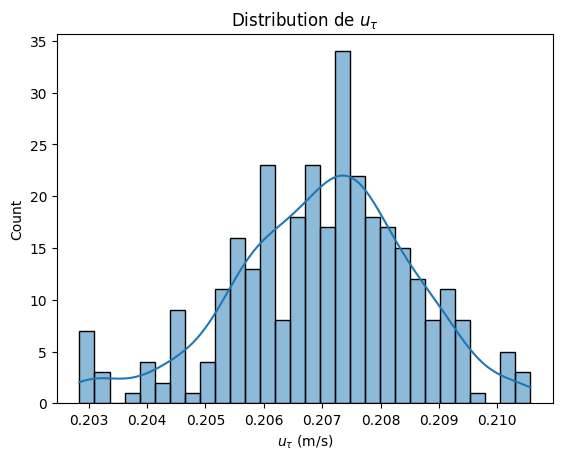

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

m.metadata_df = m.metadata_df.rename(columns={"$u_{\\tau}$" : "u_tau"})
m.metadata_df[["u_tau"]]

plt.figure()

sns.histplot(
    m.metadata_df['u_tau'],
    kde=True,
    bins=30
)

plt.xlabel(r"$u_{\tau}$ (m/s)")
plt.ylabel("Count")
plt.title("Distribution de $u_{\\tau}$")

plt.show()

## Which geographical domain do we focus on?

In [6]:
filenames_list = m.metadata_df["NameE"].unique()
filenames_list

array(['AU-Syd-U1_d00', 'AU-Syd-U2_d00', 'AU-Syd-U3_d00', 'AU-Syd-U4_d00',
       'AU-Syd-U5_d00', 'AU-Syd-U6_d00', 'AU-Syd-U7_d00', 'AU-Mel-U1_d00',
       'AU-Mel-U2_d00', 'AU-Mel-U3_d00', 'AU-Mel-U4_d00', 'AU-Mel-U5_d00',
       'AU-Mel-U6_d00', 'AU-Mel-U7_d00', 'AU-Mel-U8_d00', 'AU-Mel-U9_d00',
       'AU-Mel-U10_d00', 'AU-Mel-U11_d00', 'AU-Mel-U12_d00',
       'AU-Mel-U13_d00', 'AU-Mel-U14_d00', 'AU-Mel-U15_d00',
       'AU-Mel-U16_d00', 'AU-Mel-U17_d00', 'AU-Mel-U18_d00',
       'AU-Mel-U19_d00', 'US-Chi-U1_d00', 'US-Det-U1_d00',
       'US-Det-U2_d00', 'US-Det-U3_d00', 'US-Det-U4_d00', 'US-Det-U5_d00',
       'ES-Bar-U1_d00', 'CH-Zur-U1_d00', 'CH-Zur-U2_d00', 'CH-Bas-U1_d00',
       'NL-AMS-U1_d00', 'SG-Boo-U1_d00', 'US-Det-U6_d00', 'US-Det-U7_d00',
       'US-Det-U8_d00', 'US-Det-U9_d00', 'US-Det-U10_d00',
       'US-Los-U1_d00', 'CA-Van-U1_d00', 'CA-Van-U2_d00', 'US-Mia-U1_d00',
       'US-Mia-U2_d00', 'US-Det-U11_d00', 'US-Pho-U1_d00',
       'US-Pho-U2_d00', 'US-Pho-U3_d00',

The scenarii have been selected by stratified sampling. 

Retrieve nc file code with filename :

In [9]:
# filename = filenames_list[0]
filename = "JP-Tok-V3_d00"
print(filename)
nc_code = m.metadata_df["NameI"][m.metadata_df["NameE"] == filename].iloc[0]
if pd.isna(nc_code) or not str(nc_code).strip():
    print(f"NameI (nc file code) is empty: {nc_code}.")
nc_file = f"{nc_code}_data.nc"
nc_path = os.path.join(path_3D, nc_file)
if os.path.exists(nc_path) :
    print(f"{nc_file} found at: {nc_path}")
else :
    print(f"File not found at: {nc_path}")
    print(f"The file may already have been deleted and converted to raster layers.")

JP-Tok-V3_d00
File not found at: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/Copie_UrbanTALES/3Dwind/T17_data.nc
The file may already have been deleted and converted to raster layers.


... or retrieve filename and nc file code with country :

In [253]:
# country = "Netherland"

# scenario_list = m.retrieve_filenames(country=country)
# # nc_list = fct.list_nc_files(path_3d_folder=path_3D)
# print(scenario_list)

In [254]:
# matching = next(
#     (code_nc for code_nc, prefix in filenames_list if prefix == filename), None
# )
# if matching is not None:
#     nc_filename = f"{matching}_data.nc"
#     if nc_filename in nc_list:
#         print(f"{filename} peut être utilisé dans la pipeline.")
#     else:
#         print(f"{filename} n'a pas de fichier .nc correspondant dans nc_list.")
# else:
#     print(f"{filename} n'a pas de correspondance dans filenames_list.")

In [10]:
wind_dict = m.retrieve_wind_info(filename)
epsg = wind_dict["epsg"].to_epsg()
wind_dict

{'filename_e': 'JP-Tok-V3_d00',
 'filename_i': 'T17',
 'wind_dir': '0',
 'lon': 139.8093027777778,
 'lat': 35.69281111111111,
 'city': 'Kotobashi',
 'localisation': 'Kotobashi',
 'epsg': <Projected CRS: EPSG:32654>
 Name: WGS 84 / UTM zone 54N
 Axis Info [cartesian]:
 - E[east]: Easting (metre)
 - N[north]: Northing (metre)
 Area of Use:
 - name: Between 138°E and 144°E, northern hemisphere between equator and 84°N, onshore and offshore. Japan. Russian Federation.
 - bounds: (138.0, 0.0, 144.0, 84.0)
 Coordinate Operation:
 - name: UTM zone 54N
 - method: Transverse Mercator
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich}

Copy these coordinates in OSM Nominatim:

In [14]:
print(wind_dict.get("lat"), ",", wind_dict.get("lon"))

48.829097222222224 , 2.2757388888888888


## Load nc file

In [16]:
nc = NetCdf(
    filename_e=filename, metadata=m, path_3d_folder=path_3D, georef_input=georef_input
)

nc.nc_xr
nc.process_nc(overwrite=False)

⚠️ NetCDF file not found: %s /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/Copie_UrbanTALES/3Dwind/A8_data.nc
All rasters (.tif files) exist, no need to process NetCDF file.
Files are stored at :  /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_input/FR-Hau-V1_d00
⚠️ NetCDF file not found: %s /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/Copie_UrbanTALES/3Dwind/None_data.nc
Nc file already deleted or not found, 
If any doubt, please check the data stored in SSD support.


## Topo file to raster

Open and process to raster the topo file used in UrbanTALES associated with the `filename_e`.

To begin: add name_topo in metada. This could be filename_e or another name, please check the associated folder to confirm.

In [17]:
# Add name_topo of the domain
# filename = "US-Mia-U2_d00"
# metadata = m.metadata_df
df = m.metadata_df

# Trouver la ligne dont le NameE commence par filename
match_df = df[df["NameE"].astype(str) == str(filename)]
# match_df["angle_domain"] = pd.NA

if not match_df.empty:
    # On récupère la première correspondance
    row = match_df.iloc[0]
    if pd.notna(row.get("name_topo")):
        name_topo = str(row["name_topo"])
        print(f"Topo file name retrieved from metadata : {name_topo}")
    else:
        print("Enter the topo name manually (name_topo empty in metadata)")
        # Determine the name of topo file from associated folder
        name_topo = "CH-Bas-U1_d90"
        m.metadata_df = m.add_name_topo_to_metadata(name_topo=name_topo, filename_e=filename)

else:
    print("Enter the name of topo file manually (no correspondance in NameE)")

Topo file name retrieved from metadata : FR-PA-V1_d00


If need to change name_topo :

In [ ]:
# df = m.metadata_df
# name_topo_modified = "KO-SE-V2_d00"
# match_df = df[df["NameE"].astype(str) == str(filename)]
# if not match_df.empty:
#     row = match_df.iloc[0]
#     m.metadata_df = m.add_name_topo_to_metadata(
#         name_topo=name_topo_modified, filename_e=filename)

Name KO-SE-V2_d00 for topo file added for all prefixes of KO-Hae-V2_d00 (before _dXX)
metadata file saved locally


In [18]:
topo_test = TopoRaster(
    filename_e=filename,
    georef_input=georef_input,
    georef_output=georef_output,
    path_data=path_data,
    m=m,
)

# topo_test.dataset
# topo_test.close

[INFO] Topo file found in location: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/Copie_UrbanTALES/topo/FR-PA-V1_d00/FR-PA-V1_d00_topo
✅ Topo raster already exists at /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/Extracting_buildings/FR-Hau-V1_d00/layer_topo.tif.
✅ TopoRaster successfully initialized for FR-Hau-V1_d00.


## Georeference operation

For georeference operations, we did not compute any classes and choose to use functions instead.

In [19]:
import python_code.Package.functions as fct

fct.find_gcp(filename=filename, georef_input=georef_input)

File 'gdal_command.txt' already exists.


In [20]:
import python_code.Package.functions as fct

reload(fct)

groovy_georef_path = os.path.join(
    path_git, "urban_wind_predict", "Groovy", "WindDataGDALCommands.groovy"
)

fct.georeferencement(
    filename_e=filename,
    topo=topo_test,
    georef_input=georef_input,
    georef_output=georef_output,
    path_data=path_data,
    groovy_path=groovy_georef_path,
)

Prepare tmp folder like presented in 0_expl_tmp.
[INFO] Topo file found in location: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/Copie_UrbanTALES/topo/FR-PA-V1_d00/FR-PA-V1_d00_topo
Copying topo file...
Copying wind files...
Copying groovy script...
✅ All files have been copied to /tmp/lenaig.
Sortie standard : echo A set of GDAL commands to transform the wind images in the good projection


echo Step 1 : Extract the polygon as a geometry
echo replace NaN values to -9999
gdal_calc.py -A /tmp/lenaig/wind_layer_0.25.tif --outfile=/tmp/lenaig/results/wind_layer_0.25_nan.tif --calc='numpy.nan_to_num(A, nan=-9999)'
echo start translating... /tmp/lenaig/results/wind_layer_0.25_georef.tif
gdal_translate -of GTiff -gcp 30.206 551.241 446857.222 5408683.655 -gcp 504.774 552.818 447193.487 5409014.451 -gcp 542.874 79.07 447553.772 5408703.921 -gcp 156.992 229.265 447172.658 5408540.881 -gcp 296.105 407.131 447146.522 5408765.576 /tmp/lenaig/results/wind

'/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00'

The georeferenced topo file is loaded with another class

✅ TopoRasterGeoref successfully initialized for FR-Hau-V1_d00.
vmin = 0.0 vmax = 27.0


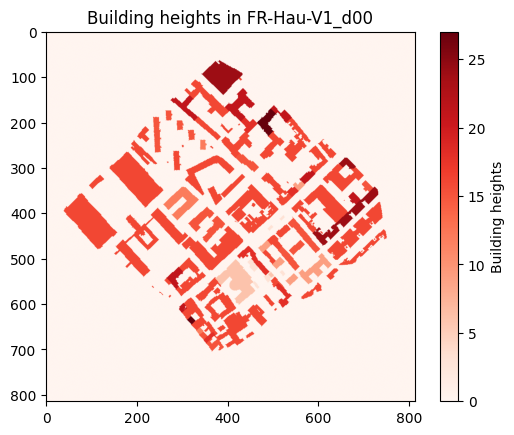

✅ GeoJSON file saved: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00/topo.geojson


In [21]:
topo_georef = TopoRasterGeoref(filename_e=filename, georef_output=georef_output)
topo_georef.to_geojson(viz=True)  # save into geojson

## Adding angle value

In [ ]:
# df = m.metadata_df
# df[df["NameE"] == "KO-Hae-U2_d00"]["angle_domain"].iloc[0]

np.float64(116.967)

In [22]:
# Add angle value of the domain
# metadata = m.metadata_df
df = m.metadata_df
# filename = "IT-Rom-V4_d00"
# Trouver la ligne dont le NameE commence par filename
match_df = df[df["NameE"].astype(str) == str(filename)]
# match_df["angle_domain"] = pd.NA

if not match_df.empty:
    # On récupère la première correspondance
    row = match_df.iloc[0]
    if pd.notna(row.get("angle_domain")):
        angle = float(row["angle_domain"])
        print(f"Angle retrieved from metadata : {angle}")
    else:
        print("Enter the angle value manually (angle_domain empty in metadata)")
        # Determine the angle value at hand with QGIS
        # angle = df[df["NameE"] == "KO-Hae-U2_d00"]["angle_domain"].iloc[0]
        # m.metadata_df = m.add_angle_to_metadata(angle=angle, filename_e=filename)

else:
    print("Renseigner à la main la valeur d'angle (aucune correspondance dans NameE)")

Angle retrieved from metadata : 44.368


If you need to change angle value :

In [ ]:
# df = m.metadata_df
# angle_modified = 56.110
# match_df = df[df["NameE"].astype(str) == str(filename)]
# if not match_df.empty:
#     row = match_df.iloc[0]
#     m.metadata_df = m.add_angle_to_metadata(
#         angle=angle_modified, filename_e=filename)

Angle 56.11 ajouté pour les préfixes de UA-Kyi-V15_d00 (avant _dXX)
metadata file saved locally


## Base grid
Construction of the base grid

grid_path:  /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00/grid_square_fixed_res_50m_center.geojson
⚠️ Grid not found or failed to load (/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00/grid_square_fixed_res_50m_center.geojson: No such file or directory) 
 Creating new grid...
Retrieve dbf file...
✅ File found: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00/wind_layer_0.25_polygon.dbf
Insight on the polygon: 
    DN                                           geometry
0   1  POLYGON ((447227.371 5409080.062, 447228.374 5...
After dissolve : 
                                             geometry  DN
0  POLYGON ((447227.371 5409080.062, 447228.374 5...   1
✅ Dissolve done.
✅ Reprojection into EPSG 32631 done.
✅ Computation of minimum oriented bounding b

<Figure size 640x480 with 0 Axes>

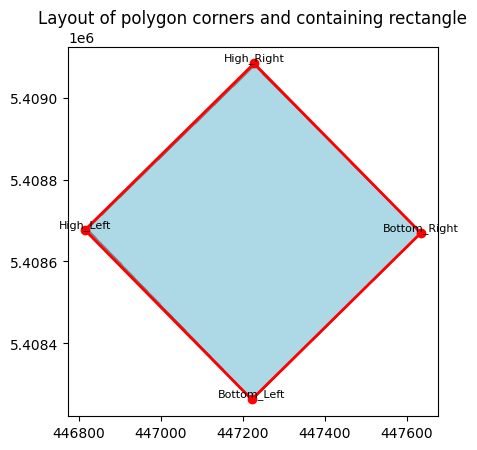

✅ CSV of corners created: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00/polygon_contour_coins.csv
ℹ️ Visualization of polygon and containing rectangle:
CRS: EPSG:32631


<Figure size 640x480 with 0 Axes>

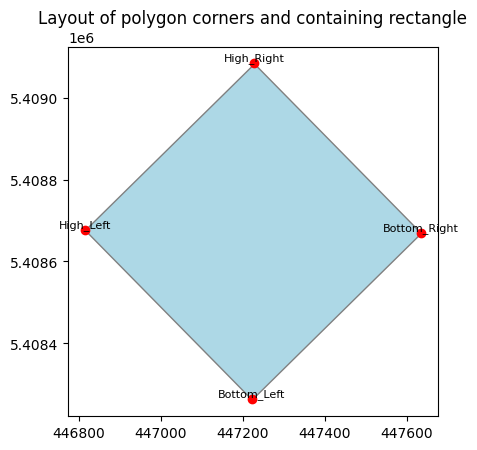

Retrieve dbf file...
✅ File found: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00/wind_layer_0.25_polygon.dbf
Insight on the polygon: 
    DN                                           geometry
0   1  POLYGON ((447227.371 5409080.062, 447228.374 5...
After dissolve : 
                                             geometry  DN
0  POLYGON ((447227.371 5409080.062, 447228.374 5...   1
✅ Dissolve done.
✅ Reprojection into EPSG 32631 done.
✅ Computation of minimum oriented bounding box done.
✅ GeoJSON created: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00/polygon_contour.geojson
✅ CSV of corners created: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00/polygon_contour_coins.csv
ℹ️ Interactive visualization of the input polygon (before inner reduction):
✅ 

/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/urban_wind_predict/python_code/Package/grid.py:506: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_map.geometry.centroid.y.iloc[0],
/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/urban_wind_predict/python_code/Package/grid.py:507: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_map.geometry.centroid.x.iloc[0],


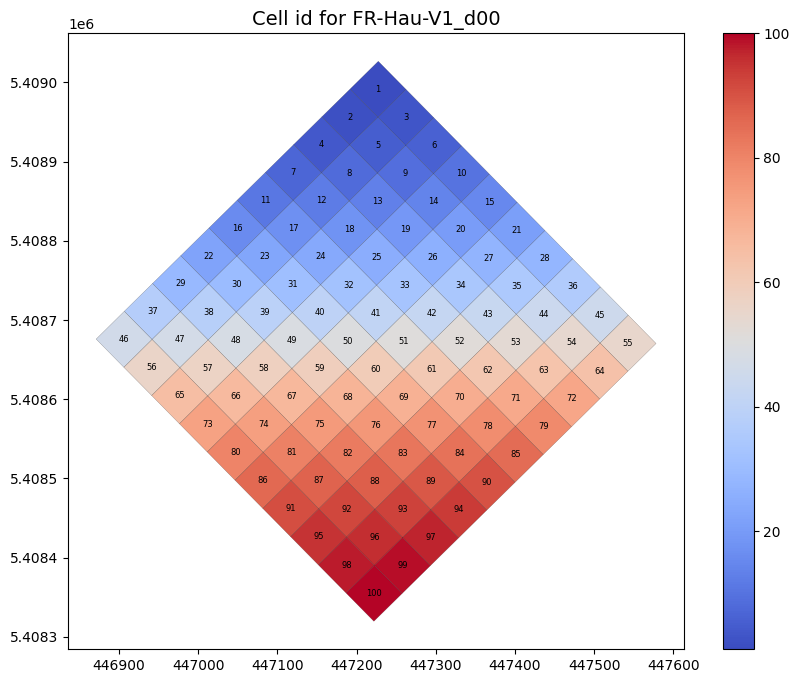

✅ Grid saved in GeoJSON: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00/grid_square_fixed_res_50m_center.geojson
✅ Grid successfully created.


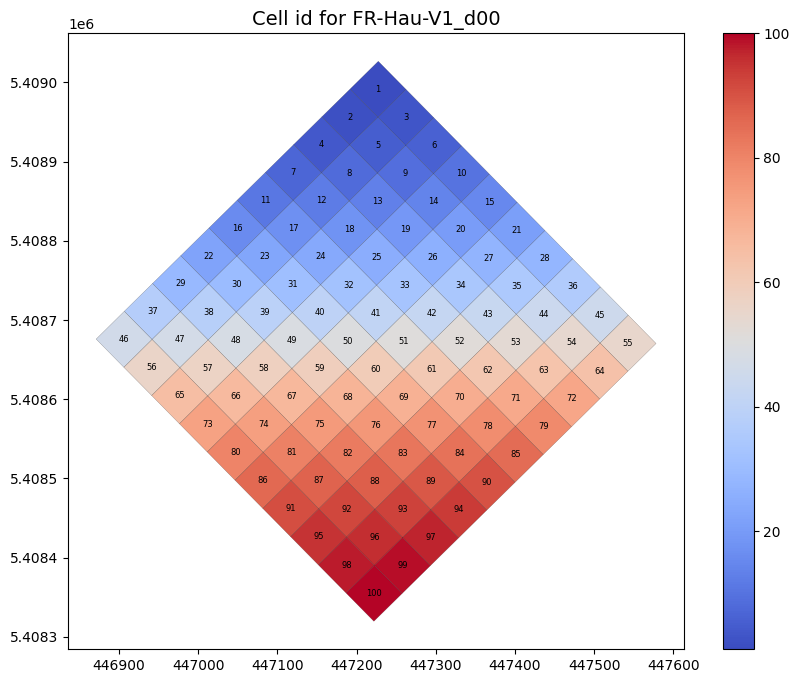

In [24]:
base_grid = Grid(
    georef_output=georef_output,
    path_data=path_data,
    filename_e=filename,
    buffer=20,
    target_resolution=50,
    epsg=epsg,
)

base_grid.gdf_grid.head()
base_grid.epsg
a = base_grid._create_cell_id(base_grid.gdf_grid)

In [16]:
base_grid.epsg

32632

## Wind grid

Creation of the wind grid from base grid

Creation of wind grid...


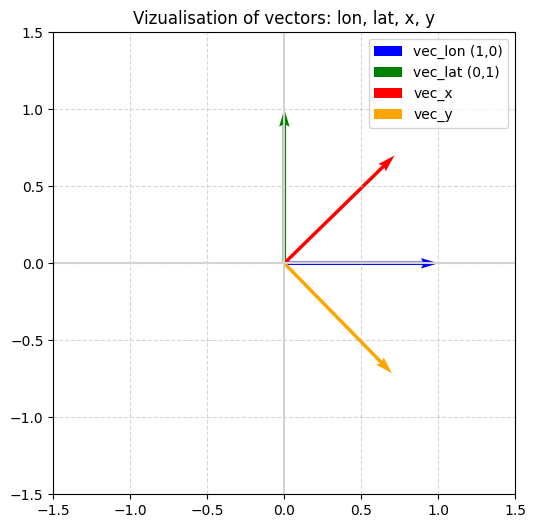


--- Processing layer z = 0.25 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 0.75 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 1.25 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 1.75 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 2.25 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 2.75 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 3.25 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 3.75 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 4.25 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 4.75 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 5.25 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 5.75 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 6.25 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 6.75 ---
Colonne 'centroid' supprimée.

--- Processing layer z = 7.25 ---
Colonne 'centroid' supprimée.

--- Processing layer z =

,geometry,x,y,cell_id,mean_w,wind_mean_lon,wind_mean_lat,speed_mean,std_w,wind_std_lon,wind_std_lat,speed_std,q25_w,wind_q25_lon,wind_q25_lat,...,angle_wind_deg,angle_wind_rad,mean_norm_speed,median_norm_speed,std_norm_speed,q25_norm_speed,q75_norm_speed,q10_norm_speed,q90_norm_speed,z,WD_deg,WD_rad,init_speed,init_lon,init_lat
0,"POLYGON ((447262.485 5408991.043, 447227.409 5...",447227.130334,5.408991e+06,1,0.004928,-0.025423,-0.005427,0.025995,0.020979,0.203181,0.012311,0.203553,0.002009,-0.183117,-0.030958,...,77.949603,1.360477,0.193757,0.195848,0.078106,0.132431,0.255525,0.090513,0.299213,0.25,134.368,2.345164,1.0,0.714863,0.699264
1,"POLYGON ((447226.852 5408955.968, 447191.776 5...",447191.497711,5.408956e+06,2,-0.007568,-0.351082,-0.351852,0.497050,0.059278,0.362684,0.051751,0.366358,-0.047081,-0.583274,-0.456793,...,44.937179,0.784302,0.562150,0.556872,0.259827,0.383255,0.766774,0.180872,0.914461,0.25,134.368,2.345164,1.0,0.714863,0.699264
2,"POLYGON ((447297.56 5408955.411, 447262.485 54...",447262.206197,5.408956e+06,3,-0.000237,-0.142277,0.281454,0.315372,0.030578,0.317885,-0.041085,0.320529,-0.007497,-0.356781,0.359553,...,153.183047,2.673549,0.402120,0.429817,0.208372,0.213365,0.563737,0.111219,0.679801,0.25,134.368,2.345164,1.0,0.714863,0.699264
3,"POLYGON ((447191.219 5408920.892, 447156.143 5...",447155.865088,5.408921e+06,4,0.001904,-0.089038,-0.183094,0.203595,0.018536,0.179142,0.062629,0.189774,-0.003837,-0.233179,-0.253622,...,25.933602,0.452627,0.246658,0.259000,0.133669,0.121487,0.361051,0.059778,0.427010,0.25,134.368,2.345164,1.0,0.714863,0.699264
4,"POLYGON ((447261.928 5408920.335, 447226.852 5...",447226.573574,5.408921e+06,5,0.002766,-0.237304,0.248475,0.343588,0.043742,0.396299,0.022493,0.396937,-0.020633,-0.509270,0.256441,...,136.317406,2.379188,0.464181,0.445063,0.256331,0.259424,0.637880,0.140085,0.864329,0.25,134.368,2.345164,1.0,0.714863,0.699264


In [26]:
wind_grid_test = WindGrid(base_grid, m)
wind_grid_test.gdf_wind_grid.head()

If necessary: modify wind direction...

In [ ]:
# wind_grid_test.rotate_WD_deg(180)

## Geo grid
Creation of the geo grid from base grid

Begin Extract Buildings....
Sortie standard : Bbox identified : [48.82561, 2.2761002, 48.831974, 2.2857344]
[description:Run the Geoclimate chain  and export result to a folder, geoclimatedb:[folder:/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00, name:gisdata1778689638060;AUTO_SERVER=TRUE, delete:true], input:[locations:[[48.82561, 2.2761002, 48.831974, 2.2857344]], delete:true, area:2500], output:[folder:[path:/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00, tables:[building, zone]]], parameters:[distance:100]]

Erreurs éventuelles : SLF4J(W): No SLF4J providers were found.
SLF4J(W): Defaulting to no-operation (NOP) logger implementation
SLF4J(W): See https://www.slf4j.org/codes.html#noProviders for further details.

Code de retour : 0
End Extract buildings
File found: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grog

<Figure size 640x480 with 0 Axes>

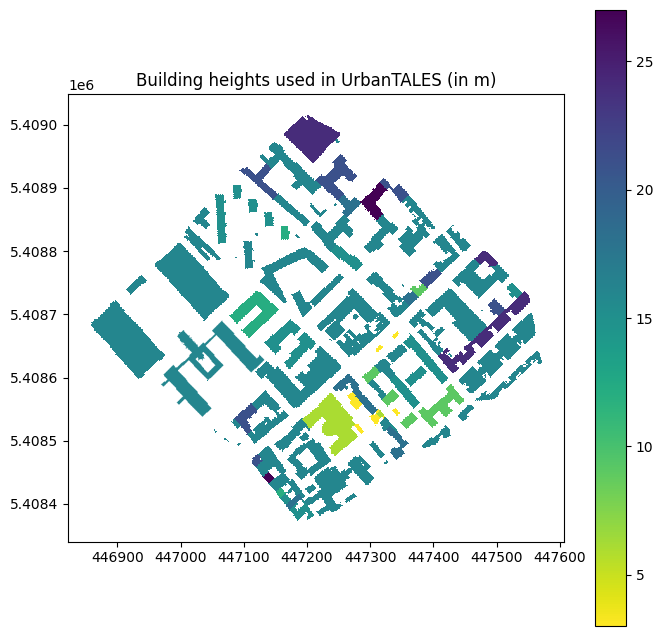

CRS of OSM file:  EPSG:32631
CRS of topo file:  EPSG:32631


<Figure size 640x480 with 0 Axes>

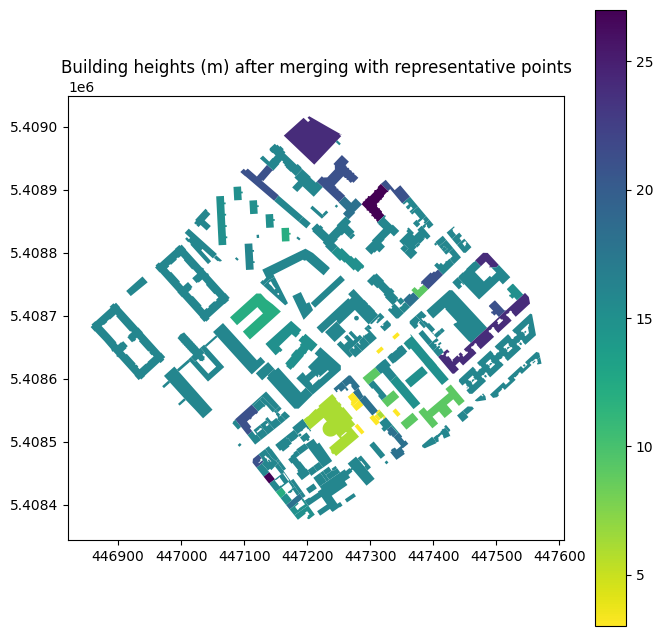

→ 258 bâtiments sans hauteur après 'within'. On tente 'intersects'.
Hauteurs attribuées à 239 / 460 bâtiments.


<Figure size 640x480 with 0 Axes>

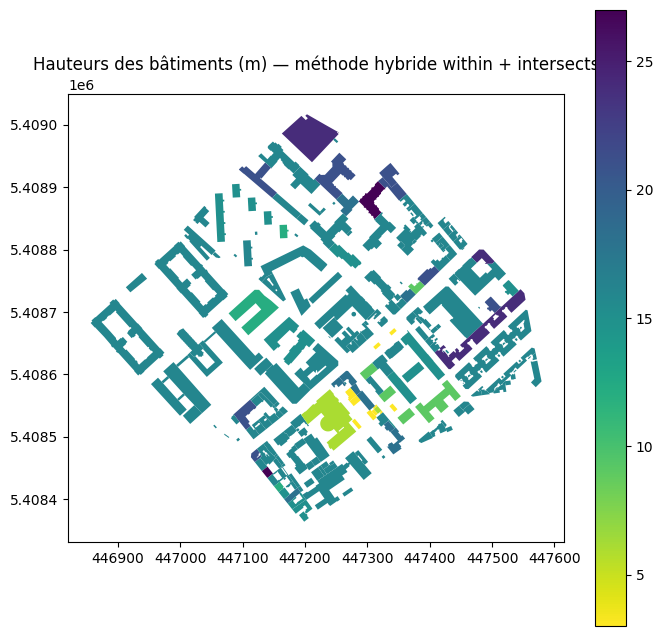

Avant nettoyage : 460 bâtiments
Après nettoyage : 239 bâtiments


/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/urban_wind_predict/venv/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Figure size 640x480 with 0 Axes>

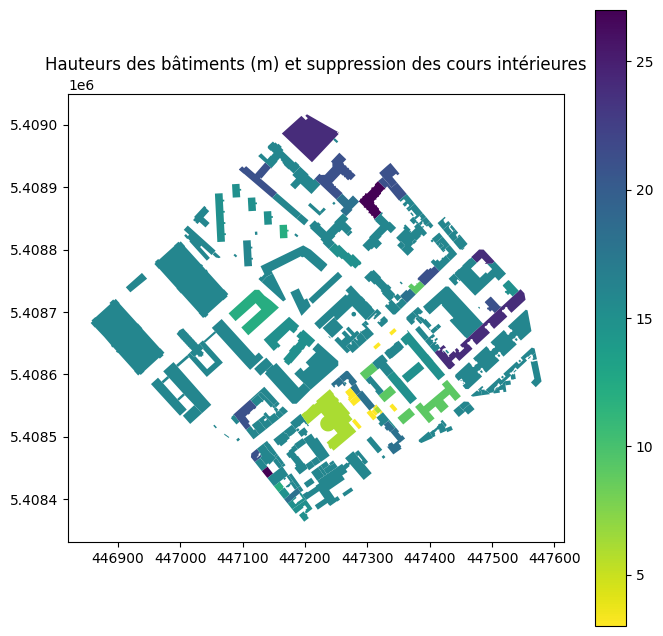

Begin extract geo from grid ...
Sortie standard : 
Erreurs éventuelles : SLF4J(W): No SLF4J providers were found.
SLF4J(W): Defaulting to no-operation (NOP) logger implementation
SLF4J(W): See https://www.slf4j.org/codes.html#noProviders for further details.

Code de retour : 0
End extract geo !


In [27]:
groovy_path_eb = os.path.join(
    path_git, "urban_wind_predict", "Groovy", "extractBuilding.groovy"
)
groovy_path_geo = os.path.join(
    path_git, "urban_wind_predict", "Groovy", "geoClimateIndicators.groovy"
)

geo_grid_test = GeoGrid(
    base_grid, groovy_path_eb=groovy_path_eb, groovy_path_geo=groovy_path_geo
)

Check if epsg codes are equals :

In [20]:
print(wind_grid_test.grid.epsg)
print(geo_grid_test.grid.epsg)

32632
32632


Insight on grids:

In [21]:
wind_grid_test.gdf_wind_grid.columns
geo_grid_test.gdf_geo_grid.head()
geo_grid_test.gdf_geo_grid.columns

Index(['CELL_ID', 'BUILDING_FRACTION', 'UNDEFINED_FRACTION', 'AVG_HEIGHT_ROOF',
       'STD_HEIGHT_ROOF', 'GEOM_AVG_HEIGHT_ROOF', 'BUILDING_NUMBER_DENSITY',
       'BLOCK_NUMBER_DENSITY', 'BUILDING_DIRECTION_EQUALITY',
       'BUILDING_DIRECTION_UNIQUENESS', 'MAIN_BUILDING_DIRECTION',
       'AVG_HEIGHT_ROOF_AREA_WEIGHTED', 'STD_HEIGHT_ROOF_AREA_WEIGHTED',
       'FREE_EXTERNAL_FACADE_DENSITY', 'ASPECT_RATIO', 'STREET_WIDTH',
       'BUILDING_SURFACE_DENSITY', 'SVF', 'PROJECTED_FACADE_DENSITY_DIR_D0_30',
       'PROJECTED_FACADE_DENSITY_DIR_D30_60',
       'PROJECTED_FACADE_DENSITY_DIR_D60_90',
       'PROJECTED_FACADE_DENSITY_DIR_D90_120',
       'PROJECTED_FACADE_DENSITY_DIR_D120_150',
       'PROJECTED_FACADE_DENSITY_DIR_D150_180',
       'EFFECTIVE_TERRAIN_ROUGHNESS_LENGTH',
       'EFFECTIVE_TERRAIN_ROUGHNESS_CLASS', 'geometry'],
      dtype='object')

## Final grid

The final grid is generated:

In [28]:
final_grid_test = FinalGrid(wind_grid=wind_grid_test, geo_grid=geo_grid_test)
# table = final_grid_test.final_grid

✅ Set GEOMETRY as active geometry for gdf1
✅ Set GEOMETRY as active geometry for gdf2
✅ Identical geometries detected: kept only one geometry column.
Saved in: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/GeoReference/Georef_output/FR-Hau-V1_d00/final_50m.geojson


In [23]:
final_grid_test.final_grid.head()

,X,Y,CELL_ID,MEAN_W,WIND_MEAN_LON,WIND_MEAN_LAT,SPEED_MEAN,STD_W,WIND_STD_LON,WIND_STD_LAT,...,SVF,PROJECTED_FACADE_DENSITY_DIR_D0_30,PROJECTED_FACADE_DENSITY_DIR_D30_60,PROJECTED_FACADE_DENSITY_DIR_D60_90,PROJECTED_FACADE_DENSITY_DIR_D90_120,PROJECTED_FACADE_DENSITY_DIR_D120_150,PROJECTED_FACADE_DENSITY_DIR_D150_180,EFFECTIVE_TERRAIN_ROUGHNESS_LENGTH,EFFECTIVE_TERRAIN_ROUGHNESS_CLASS,GEOMETRY
0,391873.844074,5.267385e+06,1,-0.002314,-0.037877,-0.068936,0.078657,0.031018,0.340850,0.262769,...,0.931056,0.038093,0.051453,0.051071,0.053386,0.041546,0.018970,0.678716,6,"POLYGON ((391903.156 5267365.731, 391893.613 5..."
1,391824.763304,5.267376e+06,2,-0.001265,-0.150619,-0.008293,0.150847,0.027228,0.270516,0.187461,...,0.912308,0.023736,0.041000,0.047804,0.049664,0.038217,0.020888,0.590158,6,"POLYGON ((391854.075 5267356.187, 391844.532 5..."
2,391775.682535,5.267366e+06,3,0.000871,-0.162169,-0.211100,0.266199,0.041497,0.199040,0.339964,...,0.898006,0.074388,0.101376,0.107744,0.105865,0.078354,0.043851,1.364209,7,"POLYGON ((391804.995 5267346.644, 391795.451 5..."
3,391726.601765,5.267357e+06,4,-0.003475,-0.173171,-0.191723,0.258353,0.049524,0.163316,0.181973,...,0.800339,0.014379,0.056886,0.084519,0.090656,0.083477,0.055723,1.028371,7,"POLYGON ((391755.914 5267337.1, 391746.37 5267..."
4,391677.520996,5.267347e+06,5,0.004335,-0.178452,-0.312421,0.359794,0.045189,0.232874,0.224065,...,0.903678,0.009111,0.049851,0.077300,0.084063,0.077149,0.049568,0.925446,7,"POLYGON ((391706.833 5267327.557, 391697.29 52..."


In [ ]:
final_grid_test.final_grid.columns

Index(['X', 'Y', 'CELL_ID', 'MEAN_W', 'WIND_MEAN_LON', 'WIND_MEAN_LAT',
       'SPEED_MEAN', 'STD_W', 'WIND_STD_LON', 'WIND_STD_LAT', 'SPEED_STD',
       'Q25_W', 'WIND_Q25_LON', 'WIND_Q25_LAT', 'SPEED_Q25', 'Q75_W',
       'WIND_Q75_LON', 'WIND_Q75_LAT', 'SPEED_Q75', 'MIN_W', 'WIND_MIN_LON',
       'WIND_MIN_LAT', 'SPEED_MIN', 'MAX_W', 'WIND_MAX_LON', 'WIND_MAX_LAT',
       'SPEED_MAX', 'ANGLE_WIND_DEG', 'ANGLE_WIND_RAD', 'MEAN_NORM_SPEED',
       'MEDIAN_NORM_SPEED', 'STD_NORM_SPEED', 'Q25_NORM_SPEED',
       'Q75_NORM_SPEED', 'Q10_NORM_SPEED', 'Q90_NORM_SPEED', 'Z', 'WD_DEG',
       'WD_RAD', 'INIT_SPEED', 'INIT_LON', 'INIT_LAT', 'BUILDING_FRACTION',
       'UNDEFINED_FRACTION', 'AVG_HEIGHT_ROOF', 'STD_HEIGHT_ROOF',
       'GEOM_AVG_HEIGHT_ROOF', 'BUILDING_NUMBER_DENSITY',
       'BLOCK_NUMBER_DENSITY', 'BUILDING_DIRECTION_EQUALITY',
       'BUILDING_DIRECTION_UNIQUENESS', 'MAIN_BUILDING_DIRECTION',
       'AVG_HEIGHT_ROOF_AREA_WEIGHTED', 'STD_HEIGHT_ROOF_AREA_WEIGHTED',
       'FRE

## Visualisation of wind 

In [ ]:
from python_code.Base_model import functions as f

In [ ]:
# filename = "FR-Par-V2_d45"
# filename = "CA-Van-V2_d90"
# filename = "UA-Kyi-V6_d90"
# filename = "FR-Hau-V1_d00"
# filename = "FR-Par-V2_d15"
# filename = "UA-Kyi-V6_d30"
# filename = "UA-Kyi-V6_d45"
# filename = "IT-Rom-V1_d90"
# filename = "IT-Rom-V2_d90"
# filename = 'UA-Kyi-V1_d90'
# filename = 'UA-Kyi-V5_d15'

<positron-console-cell-229>:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


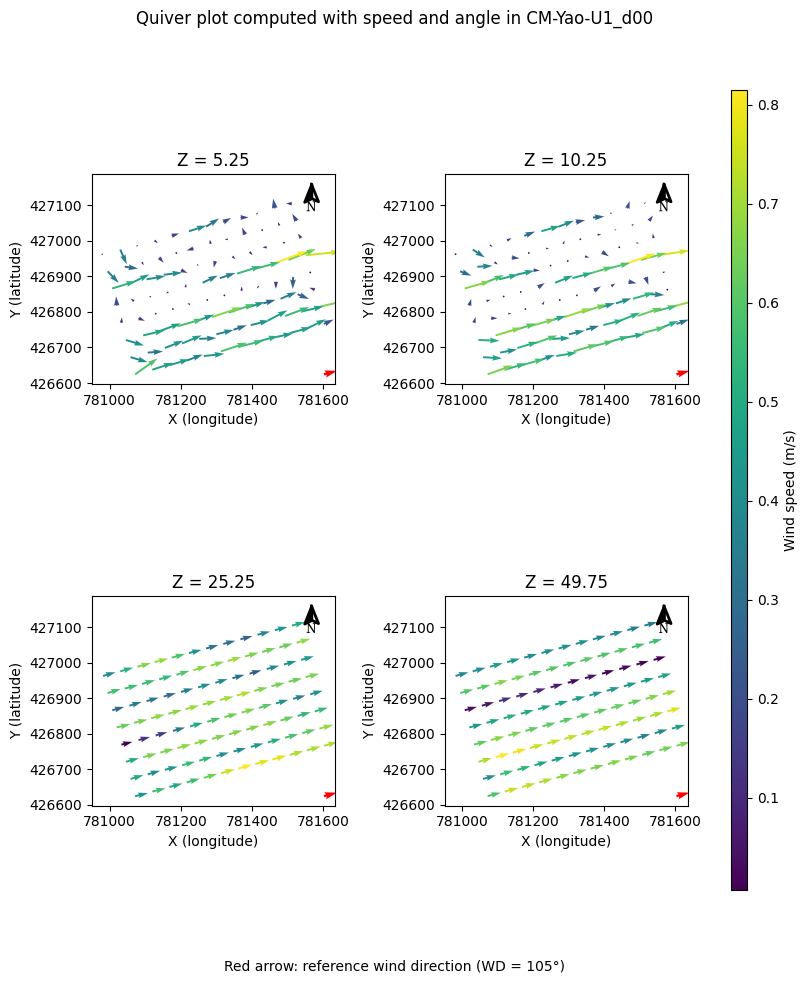

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from geo_northarrow import add_north_arrow

gdf = f.open_final_gdf(filename, res_cell=50)
name_df = filename
cmap = "viridis"

# Heights
Z = sorted(gdf["Z"].unique())
z_list = [Z[10], Z[20], Z[50], Z[99]]

# Reference location
x0 = gdf["X"].max()
y0 = gdf["Y"].min()
ymax = gdf["Y"].max() - 3

# Wind direction (mathematical convention)
WD = float(gdf["WD_DEG"].iloc[0])

# Figure with reserved space on the right for the colorbar
fig, axes = plt.subplots(2, 2, figsize=(8, 10))
axes = axes.flatten()

quiv_for_colorbar = None

for i, z in enumerate(z_list):
    df_z = gdf[gdf["Z"] == z]

    # Main quiver with increased arrow thickness
    Q = axes[i].quiver(
        df_z["X"].values,
        df_z["Y"].values,
        df_z["WIND_MEAN_LON"],
        df_z["WIND_MEAN_LAT"],
        df_z["SPEED_MEAN"],
        angles="xy",
        scale_units="xy",
        scale=None,
        cmap=cmap,
        width=0.008,  # <-- increased thickness
    )

    if quiv_for_colorbar is None:
        quiv_for_colorbar = Q

    # Red arrow for WD    
    axes[i].quiver(
        x0,
        y0,
        df_z["INIT_LON"].iloc[0],
        df_z["INIT_LAT"].iloc[0],
        color="red",
        angles="xy",
        scale_units="xy",
        scale=None,
        width=0.01,  # thicker reference arrow
        zorder=15,
    )

    # --- NorthArrow ---
    add_north_arrow(
        axes[i],
        scale=0.75,
        xlim_pos=0.9025,
        ylim_pos=0.965,
        color="#000",
        text_scaler=4,
        text_yT=-1.25,
    )

    axes[i].set_title(f"Z = {z}")
    axes[i].set_xlabel("X (longitude)")
    axes[i].set_ylabel("Y (latitude)")

# Remove unused axes
for j in range(len(z_list), len(axes)):
    fig.delaxes(axes[j])

# --- COLORBAR ON THE FAR RIGHT ---
cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
cbar = fig.colorbar(quiv_for_colorbar, cax=cbar_ax)
cbar.set_label("Wind speed (m/s)")

# --- CAPTION BELOW ---
fig.text(
    0.5,
    0.02,
    f"Red arrow: reference wind direction (WD = {WD:.0f}°)",
    ha="center",
    fontsize=10,
    color="black",
)

plt.tight_layout(rect=[0, 0.05, 0.9, 0.95])
plt.suptitle(f"Quiver plot computed with speed and angle in {name_df}", y=0.98)

plt.show()

Visualisation vent + géographie

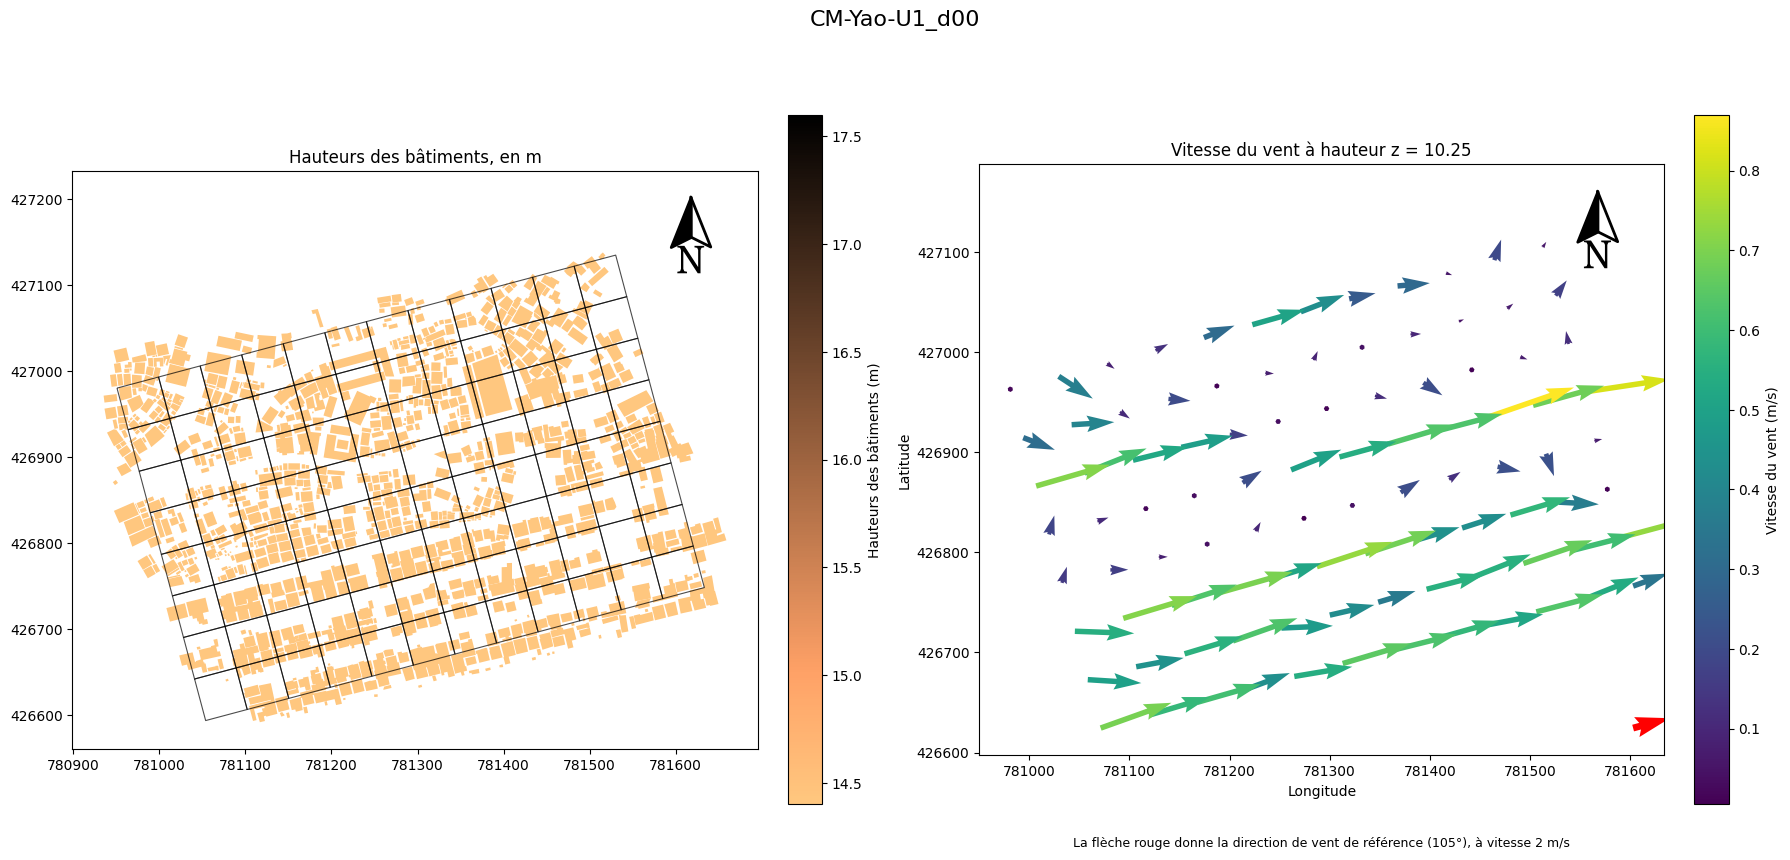

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

gdf = f.open_final_gdf(filename, res_cell=50)
name_df = filename
cmap = "viridis"
var_wind = "SPEED"
z_value = 10.25

unique_cells = sorted(gdf["CELL_ID"].unique())


# --- Grille 2 lignes x 2 colonnes ---
fig = plt.figure(figsize=(18, 9))
gs = fig.add_gridspec(1, 2)

ax_height = fig.add_subplot(gs[0, 0])  # toutes les lignes, colonne 0
ax_quiver = fig.add_subplot(gs[0, 1])  # ligne 1, colonne 1


# # ============================================================
# # --- CARTE COLORIÉE PAR AVG_HEIGHT_ROOF
# # ============================================================
gdf_height = gpd.read_file(
    os.path.join(georef_output, name_df, "buildings_with_height.geojson")
)
grid = gpd.read_file(
    os.path.join(
        georef_output, name_df, "grid_square_fixed_res_50m_center.geojson"
    )
)

gdf_height.plot(
    ax=ax_height,
    column="height",
    cmap="copper_r",
    legend=False,
    figsize=(8, 8),
)
grid.boundary.plot(
    ax=ax_height,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.7,
)
# --- NorthArrow ---
add_north_arrow(
    ax_height,
    scale=0.75,
    xlim_pos=0.9025,
    ylim_pos=0.965,
    color="#000",
    text_scaler=4,
    text_yT=-1.25,
)

# --- ScalarMappable pour la colorbar ---
norm = mpl.colors.Normalize(
    vmin=gdf_height["height"].min(),
    vmax=gdf_height["height"].max()
)
sm = mpl.cm.ScalarMappable(cmap="copper_r", norm=norm)
sm.set_array([])

# --- Colorbar ajustée au subplot ---
cbar_height = fig.colorbar(sm, ax=ax_height, fraction=0.046, pad=0.04)
cbar_height.set_label("Hauteurs des bâtiments (m)")

ax_height.set_title("Hauteurs des bâtiments, en m")

# ============================================================
# 4) QUIVER PLOT (version enrichie)
# ============================================================

# --- Données ---
gdf_z = gdf[gdf["Z"]==z_value]

X = gdf_z["X"].values
Y = gdf_z["Y"].values
U = gdf_z["WIND_MEAN_LON"]
V = gdf_z["WIND_MEAN_LAT"]
C = gdf_z["SPEED_MEAN"] # couleur = SPEED

# --- Quiver principal ---
Q = ax_quiver.quiver(
    X, Y, U, V,
    C,
    angles="xy",
    scale_units="xy",
    scale=None,
    cmap="viridis",
    width=0.008,        # épaissir les flèches
)

# Red arrow for WD    
ax_quiver.quiver(
    x0,
    y0,
    gdf_z["INIT_LON"].iloc[0],
    gdf_z["INIT_LAT"].iloc[0],
    color="red",
    angles="xy",
    scale_units="xy",
    scale=None,
    width=0.01,  # thicker reference arrow
    zorder=15,
)

# WD = float(gdf_z["WD_DEG"].iloc[0])
# theta = np.deg2rad(WD)

# u =  np.sin(theta)
# v = -np.cos(theta)

# arrow_length = 0.12

# ax_height.annotate(
#     "",
#     xy=(0.85 + u * arrow_length, 0.1 + v * arrow_length),
#     xytext=(0.85, 0.1),
#     xycoords="axes fraction",
#     arrowprops=dict(
#         arrowstyle="->",
#         color="red",
#         lw=3,
#     ),
#     zorder=15,
# )


# --- North arrow ---
add_north_arrow(
    ax_quiver,
    scale=0.75,
    xlim_pos=0.9025,
    ylim_pos=0.965,
    color="#000",
    text_scaler=4,
    text_yT=-1.25,
)
ax_quiver.set_aspect('equal')
ax_quiver.set_title(f"Vitesse du vent à hauteur z = {z_value}") # colored by speed
ax_quiver.set_xlabel("Longitude")
ax_quiver.set_ylabel("Latitude")

# --- Colorbar à droite du subplot ---
cbar = plt.colorbar(Q, ax=ax_quiver, fraction=0.046, pad=0.04)
cbar.set_label("Vitesse du vent (m/s)")

# --- Caption sous le quiver ---
ax_quiver.text(
    0.5, -0.15,
    f"La flèche rouge donne la direction de vent de référence ({WD:.0f}°), à vitesse 2 m/s",
    ha="center",
    va="center",
    transform=ax_quiver.transAxes,
    fontsize=9,
)

plt.suptitle(f"{name_df}", fontsize=16)
plt.tight_layout()

# if save_path is not None:
#     fig.savefig(save_path, dpi=300)
#     print(f"Image enregistrée sous : {save_path}")

plt.show()